# The steady Navier-Stokes equations: flow around a cylinder

We solve the steady incompressible Navier-Stokes equations

$$-\nu\,\Delta u + (u\cdot\nabla) u + \nabla p = 0, \qquad \nabla\cdot u = 0,$$

for the velocity $u = (u_1, u_2)$ and the pressure $p$, in the channel $(0, 2.2) \times (0, 0.41)$ with a cylinder of radius $0.05$ centered at $(0.2, 0.2)$ removed. This is the benchmark 2D-1 of M. Schäfer and S. Turek, *Benchmark computations of laminar flow around a cylinder* (1996). The viscosity is $\nu = 10^{-3}$ and the boundary conditions are

- at the inflow $x = 0$, the parabolic profile $u = \left(4 U y (0.41 - y)/0.41^2,\ 0\right)$ with $U = 0.3$,
- on the walls $y = 0$, $y = 0.41$ and on the cylinder, no slip, $u = 0$,
- at the outflow $x = 2.2$, the natural condition $\nu\,\partial_n u - p\,n = 0$.

The mean inflow velocity is $\bar U = 2U/3 = 0.2$ and the diameter $D = 0.1$, so the Reynolds number is $Re = \bar U D/\nu = 20$ and the flow is steady.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, div, inner, dx

**The mesh.** `fd.triangulate` meshes the channel with the cylinder as a hole, given by 64 points. `edge_markers` numbers the four sides of the channel, 1 the bottom, 2 the outflow, 3 the top and 4 the inflow, and the hole gets the next marker, 5.

11500 triangles


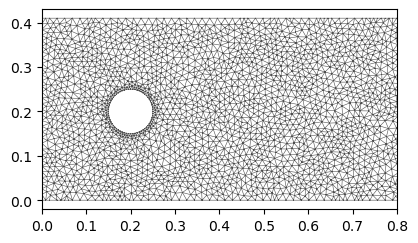

In [2]:
H = 0.41
m = fd.triangulate([(0, 0), (2.2, 0), (2.2, H), (0, H)], holes=[fd.circle(0.2, 0.2, 0.05, 64)],
                   edge_markers=[1, 2, 3, 4], max_edge=0.02, min_angle=28)
print(m.ntriangles, "triangles")

fig, ax = plt.subplots(figsize=(12, 2.6))
m.plot(ax)
ax.set_xlim(0, 0.8); ax.set_aspect("equal")
plt.show()

**The spaces.** Taylor-Hood elements, continuous $P_2$ for the velocity and $P_1$ for the pressure. The velocity data are built into the space, side by side: the inflow profile on side 4, written as an expression in `fd.y`, and zero on the walls and the cylinder. Side 2 is left free, so the outflow condition is natural.

In [3]:
x, y = fd.x, fd.y
inflow = (4 * 0.3 * y * (H - y) / H**2, 0.0)
V = fd.VectorFunctionSpace(m, 2, dirichlet={4: inflow, 1: (0, 0), 3: (0, 0), 5: (0, 0)})
Q = fd.LagrangeSpace(m, 1)
W = fd.ProductSpace(V, Q)
print(W.dim, "unknowns")

51222 unknowns


## The weak form and Newton's method

Multiplying the momentum equation by a test function $v$ that vanishes where $u$ is given, the continuity equation by a test function $q$, and integrating by parts, gives

$$R(u, p; v, q) = \nu\,(\nabla u, \nabla v) + \left((u\cdot\nabla) u, v\right) - (p, \nabla\cdot v) - (q, \nabla\cdot u) = 0$$

for every $(v, q)$. The boundary term $\int \left(\nu\,\partial_n u - p\,n\right)\cdot v\,ds$ vanishes, since $v = 0$ on the inflow, the walls and the cylinder, and the outflow condition holds on side 2. In FEMd, $(u\cdot\nabla) u \cdot v$ is `dot(dot(grad(u), u), v)`.

The problem is nonlinear. `fd.newton` solves $R = 0$ by Newton's method with the exact Jacobian, which it computes from the form symbolically. The unknown `w` is a Function of `W.unconstrained`, which holds the boundary data, and Newton changes only its free values. It starts from $u = 0$, $p = 0$.

In [4]:
nu = 0.001
w = fd.Function(W.unconstrained)
u, p = w
v, q = fd.TestFunctions(W)

R = fd.form((nu * inner(grad(u), grad(v)) + dot(dot(grad(u), u), v) - p * div(v) - q * div(u)) * dx)
info = fd.newton(R, w)
print(info.iterations, "Newton iterations, ||R|| =", "  ".join(f"{r:.1e}" for r in info.residuals))

5 Newton iterations, ||R|| = 1.4e-02  1.6e-03  2.9e-04  1.5e-05  5.3e-08  5.5e-13


**The flow.** The speed $|u|$ and the pressure $p$.

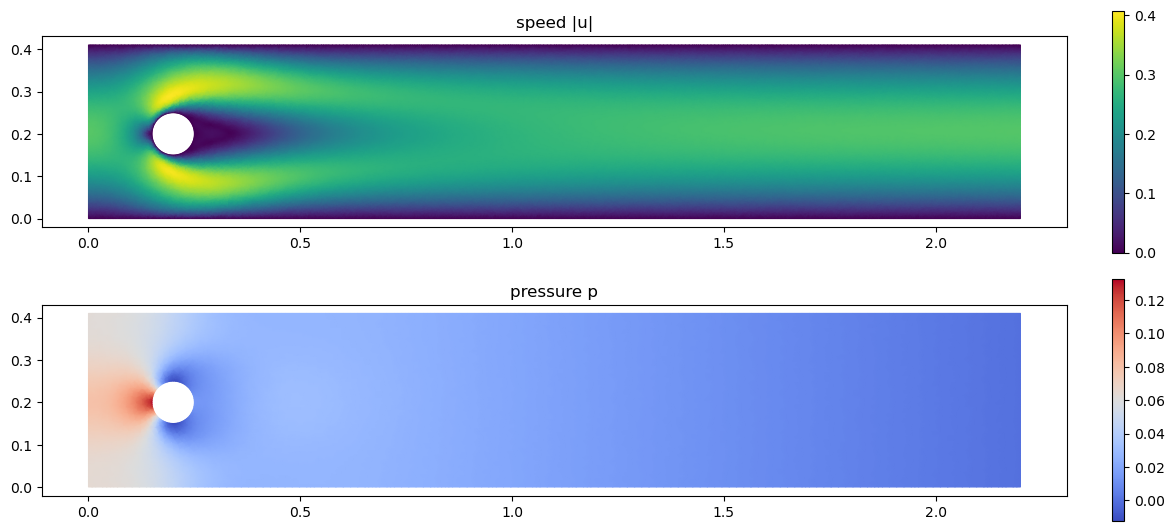

In [5]:
uh, ph = w.split()
fig, axs = plt.subplots(2, 1, figsize=(12, 5.5))
uh.plot(axs[0], quiver=False, cmap="viridis")
axs[0].set_title("speed |u|")
ph.plot(axs[1], cmap="coolwarm")
axs[1].set_title("pressure p")
for ax in axs:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## The benchmark quantities

**Pressure difference** between the front and the back of the cylinder, $\Delta p = p(0.15, 0.2) - p(0.25, 0.2)$.

**Drag and lift.** The force of the fluid on the cylinder is an integral of the stress over its surface. On a polygonal cylinder it is more accurate to compute it as a volume integral. Take a smooth function $\phi$ equal to 1 on the cylinder and 0 near the outer boundary. Integrating the momentum equation against $\Phi = (\phi, 0)$ by parts, the only boundary term left is the integral over the cylinder, which is the drag $F_D$. So

$$F_D = -\left[\nu\,(\nabla u, \nabla \Phi) + \left((u\cdot\nabla) u, \Phi\right) - (p, \nabla\cdot\Phi)\right], \qquad \Phi = (\phi, 0),$$

and the lift $F_L$ is the same with $\Phi = (0, \phi)$. We take $\phi = 1 - 3s^2 + 2s^3$ with $s = (r - 0.05)/0.1$ cut to $[0, 1]$, where $r$ is the distance from the center of the cylinder, so $\phi = 1$ on the cylinder and $\phi = 0$ for $r \ge 0.15$. Each force is a form of rank 0, a number. The coefficients are

$$c_D = \frac{2 F_D}{\bar U^2 D}, \qquad c_L = \frac{2 F_L}{\bar U^2 D}.$$

In [6]:
dp = ph.at(np.array([[0.15, 0.2]]))[0] - ph.at(np.array([[0.25, 0.2]]))[0]

r = fd.sqrt((x - 0.2)**2 + (y - 0.2)**2)
s = fd.min_value(1.0, fd.max_value(0.0, (r - 0.05) / 0.1))
phi = 1 - 3 * s**2 + 2 * s**3

Phi = fd.as_vector([phi, 0.0])
FD = -fd.form((nu * inner(grad(uh), grad(Phi)) + dot(dot(grad(uh), uh), Phi) - ph * div(Phi)) * dx).assemble()
Phi = fd.as_vector([0.0, phi])
FL = -fd.form((nu * inner(grad(uh), grad(Phi)) + dot(dot(grad(uh), uh), Phi) - ph * div(Phi)) * dx).assemble()

cD, cL = 2 * FD / (0.2**2 * 0.1), 2 * FL / (0.2**2 * 0.1)
print(f"{'':>10} {'c_D':>8} {'c_L':>9} {'dp':>8}")
print(f"{'FEMd':>10} {cD:8.4f} {cL:9.5f} {dp:8.4f}")
print(f"{'reference':>10} {5.5795:8.4f} {0.010619:9.5f} {0.11752:8.4f}")

                c_D       c_L       dp
      FEMd   5.5763   0.01028   0.1175
 reference   5.5795   0.01062   0.1175


The reference values are those of the FEATFLOW group for this benchmark. With about $5 \cdot 10^4$ unknowns the drag and the pressure difference agree to about 0.1 per cent and the lift to about 1.5 per cent. A finer mesh near the cylinder, for example with `fd.bisect_triangles`, brings them closer.